# House Prices Dataset

link : https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [118]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [119]:
print(df.shape)

(1460, 81)


In [120]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Feature engineering

In [121]:
# Drop irrelevant columns

df = df.drop(columns=['Id'], errors='ignore')

In [122]:
df.head(1)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


# Handling missing data

In [123]:
# Check missing values count
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [124]:
missing_percentage = df.isnull().mean().sort_values(ascending=False)
missing_percentage

# Percentage of TRUE in Total values

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
                 ...   
Heating        0.000000
HeatingQC      0.000000
MSZoning       0.000000
1stFlrSF       0.000000
SalePrice      0.000000
Length: 80, dtype: float64

In [125]:
# Drop columns with too many missing value

threshold = 0.65
columns_with_high_null_values = missing_percentage[missing_percentage > threshold].index.tolist()

In [126]:
columns_with_high_null_values

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [127]:
df_1 = df.drop(columns=columns_with_high_null_values, errors='ignore')

In [128]:
print(df_1.shape)

(1460, 76)


In [129]:
import numpy as np

In [130]:
# Filter by importance
# (Correlation with salePrice)

target_coorelation = df_1.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()

In [131]:
target_coorelation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [132]:
low_imapct_threshold = 0.1

# Interview Question : coorelation vs covariance
# Always use coorelation

low_impact_cols = target_coorelation[target_coorelation<low_imapct_threshold].index.to_list()
low_impact_cols

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [133]:
df_2 = df_1.drop(columns=low_impact_cols, errors='ignore')

In [134]:
df_2.shape

(1460, 66)

In [135]:
# Removing multi-collinearity

corr_matrix = df_2.select_dtypes(include=[np.number]).corr().abs()

corr_matrix

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,1.000000,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,0.426095,1.000000,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,0.251646,0.105806,1.000000,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,0.123349,0.014228,0.572323,1.000000,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.592855,1.000000,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,0.193458,0.104160,0.411876,0.315707,0.179618,1.000000,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,0.249503,0.128451,0.264736,1.000000,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,0.132644,0.002618,0.308159,0.149040,0.181133,0.114442,0.495251,1.000000,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,0.392075,0.260833,0.537808,0.391452,0.291066,0.363936,0.522396,0.415360,1.000000,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,0.457181,0.299475,0.476224,0.281986,0.240379,0.344501,0.445863,0.317987,0.819530,1.000000,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [136]:
np.triu(np.ones(corr_matrix.shape), k=1)

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],


In [137]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [138]:
np.tril(np.ones((4,4)), k=-1)

array([[0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 0.]])

In [139]:
# upper

In [140]:
upper.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='object')

In [141]:
redundant_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print(redundant_cols)

# removing redudant columns

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [142]:
df_3 = df_2.drop(columns=redundant_cols, errors='ignore')

In [143]:
df_3.shape

(1460, 62)

# Part-2

In [144]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   object 
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   object 
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   Utilities      1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  Condition2     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   object 
 18  RoofMatl

In [145]:
df_3.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [146]:
missing_values = df_3.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

In [147]:
missing_values

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
dtype: int64

In [148]:
temp_df = df_3.dropna() 
temp_df.shape

# Issue, removes too many rows just to have a clean data

(299, 62)

### Simple Imputation

Instead of deleting, we fill the missing values with estimates.

(a) Mean Imputation (Numerical Data)

(b) Median Imputation (Numerical Data)

(c) Mode Imputation (Categorical Data)


In [149]:
# (a) Mean Imputation (Numerical Data)
# LotFrontage
# Pull distribution towards the mean --> underestimates variance.

df_mean = df_3.copy()
df_mean.fillna({"LotFrontage" : df_mean["LotFrontage"].mean()}, inplace=True)

In [150]:
# (a) Median Imputation (Numerical Data)
# LotFrontage
# Robust for outliers

df_median = df_3.copy()
df_median.fillna({"LotFrontage" : df_median["LotFrontage"].median()}, inplace=True)

In [151]:
# (a) Mode Imputation (Cetegorical Data)
# LotFrontage

df_mode = df_3.copy()

In [152]:
df_mode['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [153]:
df_mode["GarageType"].mode()[0]

'Attchd'

In [154]:
df_mode.fillna({"GarageType" : df_mode["GarageType"].mode()[0]}, inplace=True)

# Compare Before and After Imputation

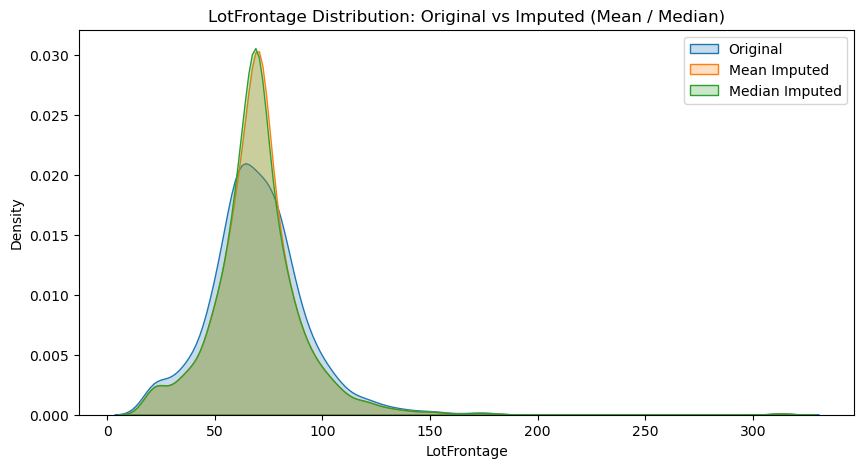

In [155]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()

In [156]:
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

### KNN Imputation

K-nearest neighbour --> ML Algorithm

In [157]:
# !pip install scikit-learn

In [158]:
from sklearn.impute import KNNImputer

In [159]:
knn_imputer = KNNImputer(n_neighbors=5)

In [160]:
df_knn = df_3.copy()

In [161]:
# MasVnrType      872
# FireplaceQu     690
# LotFrontage     259
# GarageType       81
# GarageQual       81
# GarageFinish     81
# GarageCond       81
# BsmtFinType2     38
# BsmtExposure     38
# BsmtQual         37
# BsmtFinType1     37
# BsmtCond         37
# MasVnrArea        8
# Electrical        1

In [162]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols


Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='object')

In [163]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [164]:
compare_imputation(df_3, df_knn, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,68.4
42,NaN,69.6
43,NaN,70.6
50,NaN,77.8
64,NaN,76.4


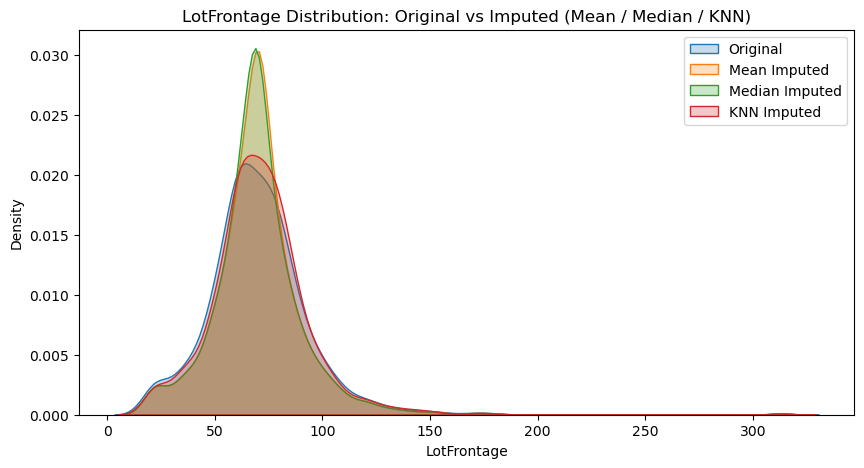

In [165]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

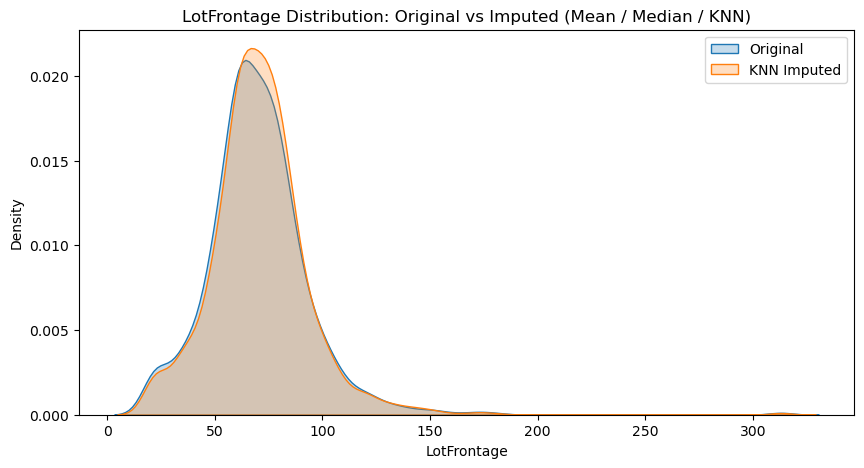

In [166]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
# sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

### Regression Imputation (Advanced)

In [167]:
from sklearn.linear_model import LinearRegression

In [168]:
df_reg = df_3.copy()

In [169]:
train_data = df_reg.dropna(subset=["LotFrontage"]) # drop the rows where LotFrontage has null values
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [170]:
# train_data.info()

In [171]:
target_coorelation_ml = train_data.select_dtypes(include=[np.number]).corr()['LotFrontage'].abs()
target_coorelation_ml

LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [172]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   object 
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   object 
 4   LotShape       1201 non-null   object 
 5   LandContour    1201 non-null   object 
 6   Utilities      1201 non-null   object 
 7   LotConfig      1201 non-null   object 
 8   LandSlope      1201 non-null   object 
 9   Neighborhood   1201 non-null   object 
 10  Condition1     1201 non-null   object 
 11  Condition2     1201 non-null   object 
 12  BldgType       1201 non-null   object 
 13  HouseStyle     1201 non-null   object 
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   object 
 18  RoofMatl     

In [173]:
X_train = train_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]]
y_train = train_data["LotFrontage"]


In [174]:
reg = LinearRegression()

In [175]:
reg.fit(X_train, y_train)

LinearRegression()

In [176]:
reg.coef_

array([ 8.90135199e-04, -1.49550808e+00,  1.24430130e-02,  1.16904327e-02])

In [177]:
test_data.head(1)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
7,RL,NaN,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,235,204,228,0,WD,Normal,200000


In [178]:
test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LotArea      259 non-null    int64
 1   OverallQual  259 non-null    int64
 2   TotalBsmtSF  259 non-null    int64
 3   GrLivArea    259 non-null    int64
dtypes: int64(4)
memory usage: 10.1 KB


In [179]:
test_data.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
7,RL,NaN,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,235,204,228,0,WD,Normal,200000
12,RL,NaN,12968,Pave,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,140,0,0,176,WD,Normal,144000
14,RL,NaN,10920,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,...,TA,TA,Y,0,213,176,0,WD,Normal,157000
16,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,...,TA,TA,Y,0,0,0,0,WD,Normal,149000
24,RL,NaN,8246,Pave,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,406,90,0,0,WD,Normal,154000


In [180]:
df_reg["LotFrontage"].isnull().head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9    False
Name: LotFrontage, dtype: bool

In [181]:
train_data.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [182]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"] = reg.predict(test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])

In [183]:
compare_imputation(df_3, df_reg, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
31,NaN,69.263614
42,NaN,60.980342
43,NaN,62.848844
50,NaN,69.936893
64,NaN,74.307034


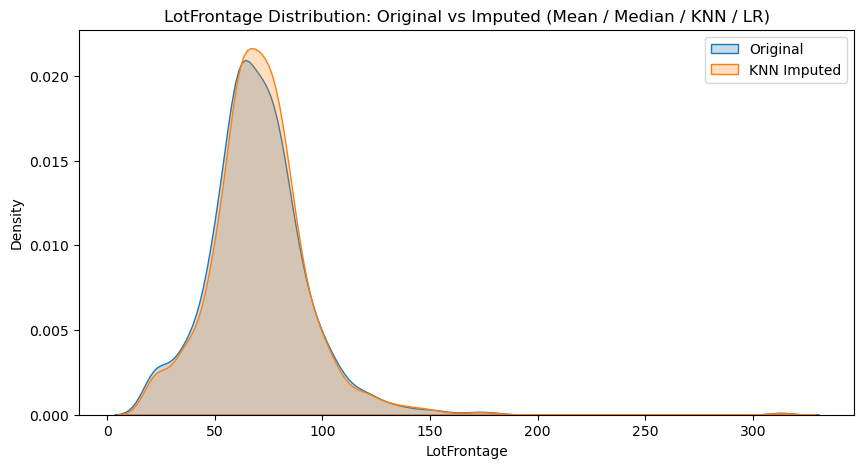

In [184]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df_3["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
# sns.kdeplot(df_reg["LotFrontage"], label="LinearRegression Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN / LR)")
plt.show()

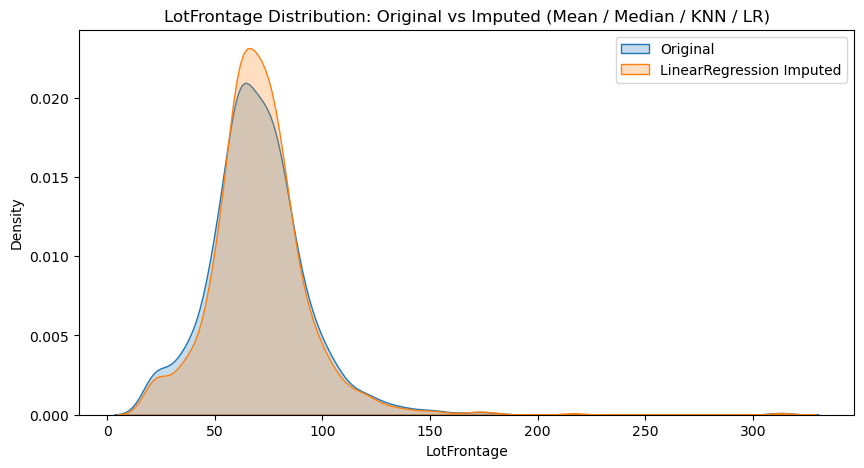

In [185]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df_3["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
sns.kdeplot(df_reg["LotFrontage"], label="LinearRegression Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN / LR)")
plt.show()

### Filling missing values using Iterative Imputer (MICE)

In [186]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

In [187]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [188]:
cols_to_use = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "1stFlrSF", "GrLivArea", "GarageYrBlt", "MasVnrArea"]

In [189]:
df[cols_to_use].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [190]:
df_subset = df[cols_to_use].copy()

In [191]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [192]:
iter_imput = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=10)

In [193]:
df_subset_imputed_values = iter_imput.fit_transform(df_subset)

In [194]:
df_subset[cols_to_use] = df_subset_imputed_values

In [195]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   OverallCond  1460 non-null   float64
 4   1stFlrSF     1460 non-null   float64
 5   GrLivArea    1460 non-null   float64
 6   GarageYrBlt  1460 non-null   float64
 7   MasVnrArea   1460 non-null   float64
dtypes: float64(8)
memory usage: 91.4 KB


# Handling Outliers

In [196]:
df = df_3

In [197]:
df.head(2)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500


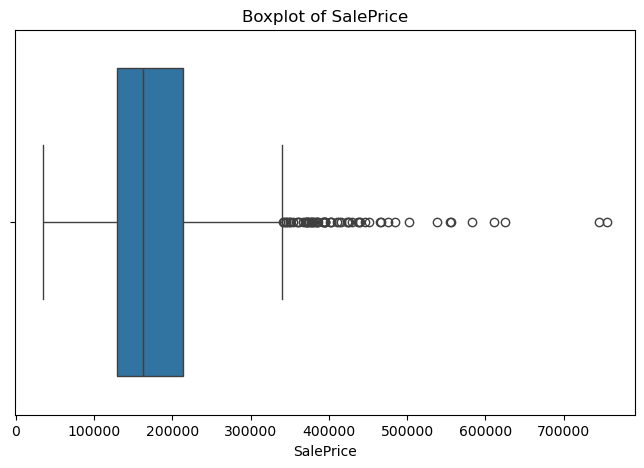

In [198]:
# Visualizing Outliers

plt.figure(figsize=(8,5))
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.show()

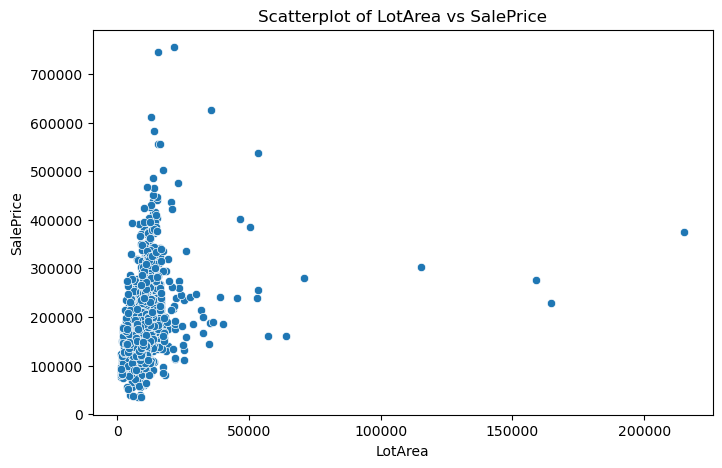

In [199]:
# Scatter plot LotArea vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("Scatterplot of LotArea vs SalePrice")
plt.show()

In [200]:
# Assigment : 
# Find important features
# all important feature scatter plot w.r.t saleprice

In [201]:
# IQR method (Interquartile Range)

# outliers = values outside [Q1 - 1.5xIQR , Q3 + 1.5xIQR]

In [202]:
import numpy

In [203]:
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]
    return outliers[[col]]

In [204]:
outliers_saleprice = detect_outliers(df, "SalePrice")

In [205]:
print(f"No. of outliers in SalePrice : {len(outliers_saleprice)}")
display(outliers_saleprice.head())

No. of outliers in SalePrice : 61


,SalePrice
11,345000
53,385000
58,438780
112,383970
151,372402


In [206]:
# how to check if data is normally distributed

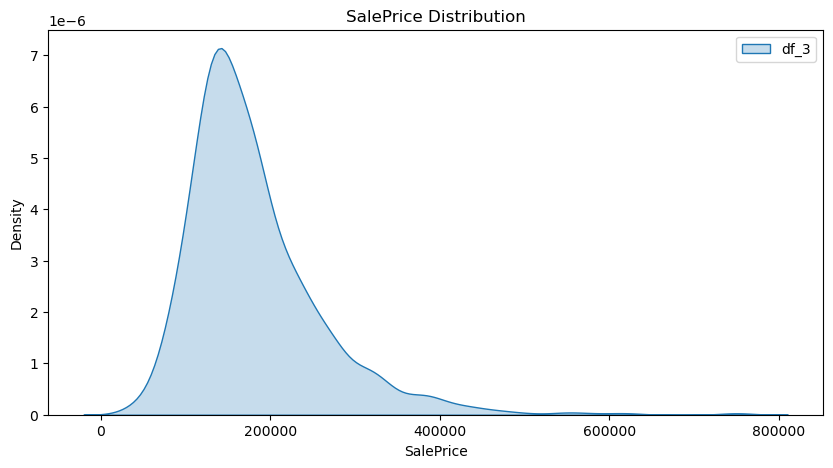

In [207]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["SalePrice"], label="df_3", fill=True)
plt.legend()
plt.title("SalePrice Distribution")
plt.show()

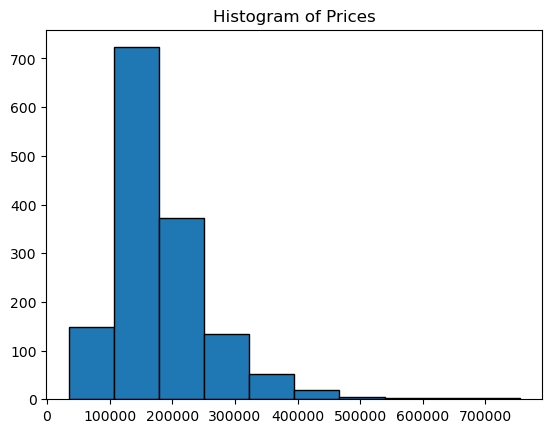

In [208]:
plt.hist(df['SalePrice'], bins=10, edgecolor='black')
plt.title("Histogram of Prices")
plt.show()

In [209]:
import scipy.stats as stats

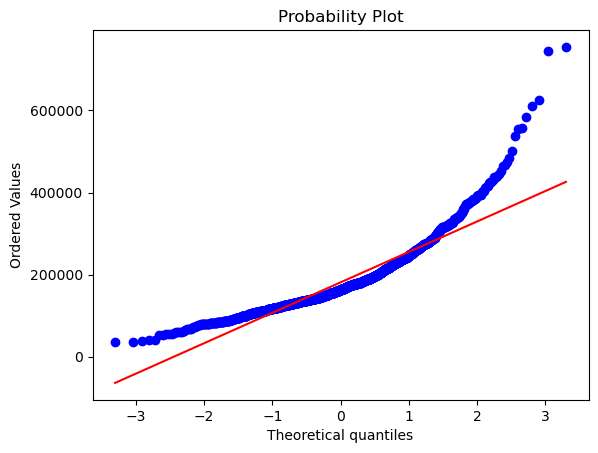

In [210]:
# Q-Q Plot

# if points follow a diagonal line,data is normal
stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.show()

In [211]:
# Shapiro-Wilk Test -> Normal or not
alpha = 0.05
# H0 is : Data is normal
# H1 : Otherwise


stat, p = stats.shapiro(df['SalePrice'])
print("Shapiro-Wilk Test p-value:", p)
if p > alpha:
    print("Data looks normal")
else:
    print("Data is NOT normal")

# 95% -> 5% error
# 99% -> 1% error

Shapiro-Wilk Test p-value: 3.2061412312021656e-33
Data is NOT normal


In [212]:
from scipy.stats import zscore

In [213]:
df["SalePrice_z"] = zscore(df["SalePrice"])
outliers_z = df[df["SalePrice_z"].abs() > 3]

In [214]:
print(f"Number of outliers in SalePrice (Z-score): {len(outliers_z)}")
outliers_z[["SalePrice", "SalePrice_z"]].head()

Number of outliers in SalePrice (Z-score): 22


,SalePrice,SalePrice_z
58,438780,3.246967
178,501837,4.040982
185,475000,3.703050
349,437154,3.226492
389,426000,3.086040


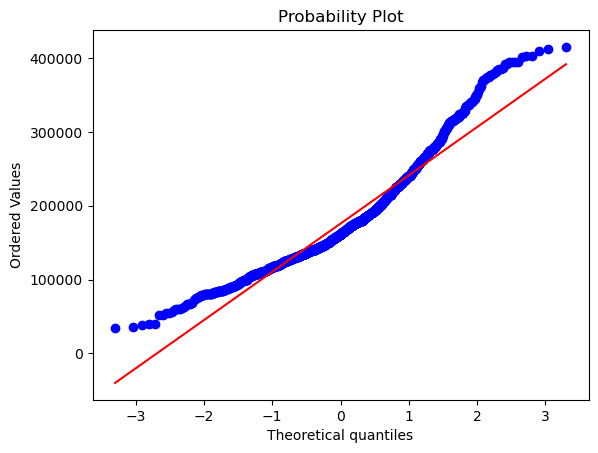

In [215]:
# QQ PLot without outliers in SalePrice

without_outliers_z = df[df["SalePrice_z"].abs() <= 3]
stats.probplot(without_outliers_z['SalePrice'], dist="norm", plot=plt)
plt.show()

In [216]:
# modified z-score

In [217]:
from scipy.stats import median_abs_deviation

In [218]:
median = df["SalePrice"].median()
mad = median_abs_deviation(df["SalePrice"])
cons_m_zscore = 0.6745

df["SalePrice_mod_z"] = cons_m_zscore * (df["SalePrice"] - median) / mad

outliers_mod_z = df[df["SalePrice_mod_z"].abs() > 3.5]

In [219]:
print(f"Number of outliers(Modified Z-score) in SalePrice : {len(outliers_mod_z)}")
outliers_mod_z[["SalePrice", "SalePrice_z", "SalePrice_mod_z"]].head()

Number of outliers(Modified Z-score) in SalePrice : 51


,SalePrice,SalePrice_z,SalePrice_mod_z
53,385000,2.569767,3.940500
58,438780,3.246967,4.895095
112,383970,2.556797,3.922217
151,372402,2.411133,3.716886
161,412500,2.916048,4.428625


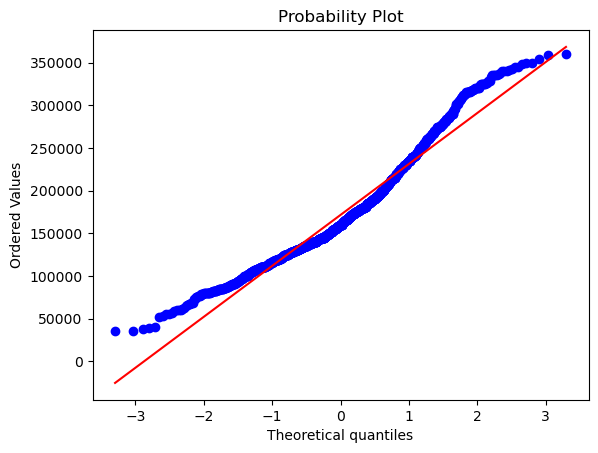

In [220]:
# QQ PLot without outliers in SalePrice (Z-score mod)

without_outliers_z_mod = df[df["SalePrice_mod_z"].abs() <= 3.5]
stats.probplot(without_outliers_z_mod['SalePrice'], dist="norm", plot=plt)
plt.show()

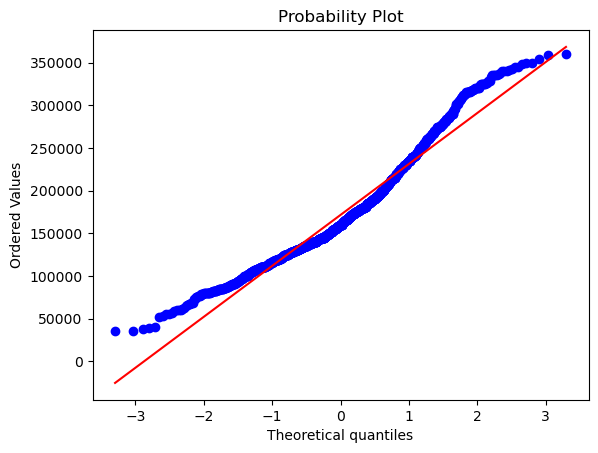

In [221]:
# QQ PLot without outliers in SalePrice (Z-score mod v2)
lower = -3.5
higher = 3.5
without_outliers_z_mod_v2 = df[(df["SalePrice_mod_z"] >= lower) & (df["SalePrice_mod_z"] <= higher)]
stats.probplot(without_outliers_z_mod_v2['SalePrice'], dist="norm", plot=plt)
plt.show()

In [222]:
# Winsorization (Capping Extreme Values)
# Instead of deleting outliers, we cap them to a limit.

In [223]:
# !pip install feature_engine

In [224]:
from feature_engine.outliers import Winsorizer

In [225]:
winsor = Winsorizer(capping_method="quantiles", tail="both", fold=0.05, variables=["SalePrice"])
df_winsor = winsor.fit_transform(df)

c:\Users\sande\anaconda3\Lib\site-packages\feature_engine\outliers\base_outlier.py:87: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[feature] = X[feature].clip(upper=self.right_tail_caps_[feature])


In [226]:
# manual calculation
# Calculate the 5th and 95th percentiles
percentile_5 = df["SalePrice"].quantile(0.05)
percentile_95 = df["SalePrice"].quantile(0.95)

print(f"5th percentile of SalePrice: {percentile_5}")
print(f"95th percentile of SalePrice: {percentile_95}")

5th percentile of SalePrice: 88000.0
95th percentile of SalePrice: 326099.9999999999


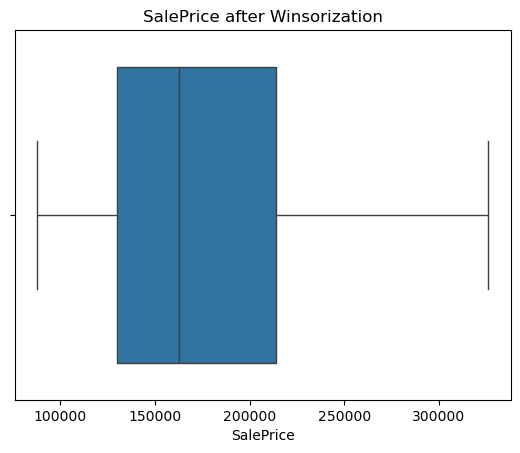

In [227]:
sns.boxplot(x=df_winsor["SalePrice"])
plt.title("SalePrice after Winsorization")
plt.show()

In [228]:
print(df.shape[0])
print(df_winsor.shape[0])

1460
1460


In [229]:
def compare_outliers(original_df, modified_df, column):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.boxplot(x=original_df[column])
    plt.title(f"{column} - Before")

    plt.subplot(1,2,2)
    sns.boxplot(x=modified_df[column])
    plt.title(f"{column} - After")
    
    plt.show()

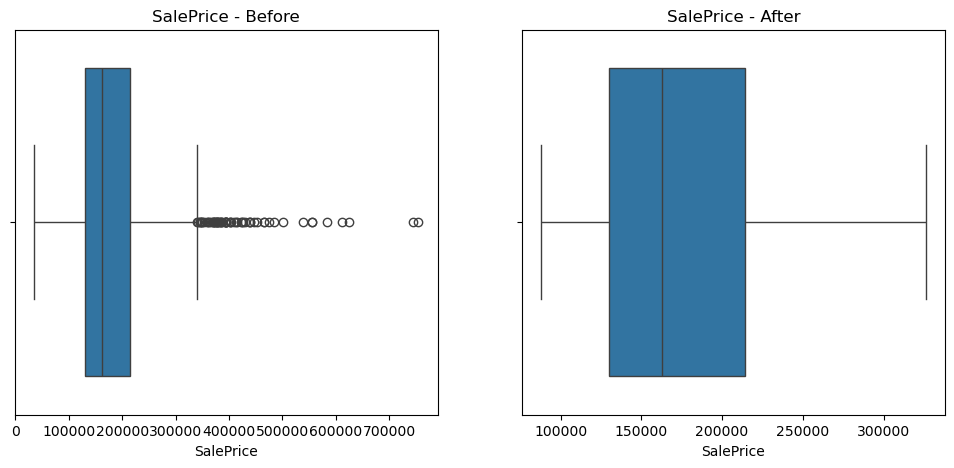

In [230]:
compare_outliers(df, df_winsor, "SalePrice")

# Feature Scaling

In [236]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

In [240]:
#Utility
def summary_stats(series):
    return{
        "mean":series.mean(),
        "std":series.std(),
        "skewness":series.skew()    
    }

In [238]:
def compare_distribution(original, transformed, title):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(original, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"{title} - Before")
    sns.histplot(transformed, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{title} - After")
    plt.show()

Before: {'mean': 70.04995836802665, 'std': 24.284751774483183, 'skewness': 2.1635691423248837}
After: {'mean': -2.677107310003708e-16, 'std': 1.0004165798972606, 'skewness': 2.1635691423248846}


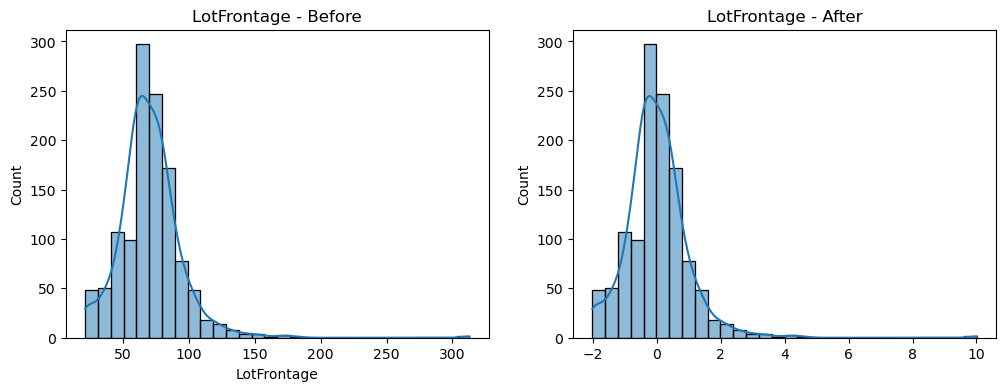

In [241]:
# ---------------------------------------------------
# 1. Standard Scaling (Normal-like data: LotFrontage)
# Formula: z = (x - μ) / σ
# ---------------------------------------------------

col = "LotFrontage"
scaler = StandardScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col], lot_scaled.flatten(), col)

Before: {'mean': 70.04995836802665, 'std': 24.284751774483183, 'skewness': 2.1635691423248837}
After: {'mean': 0.1679793094795433, 'std': 0.08316695813179194, 'skewness': 2.1635691423248846}


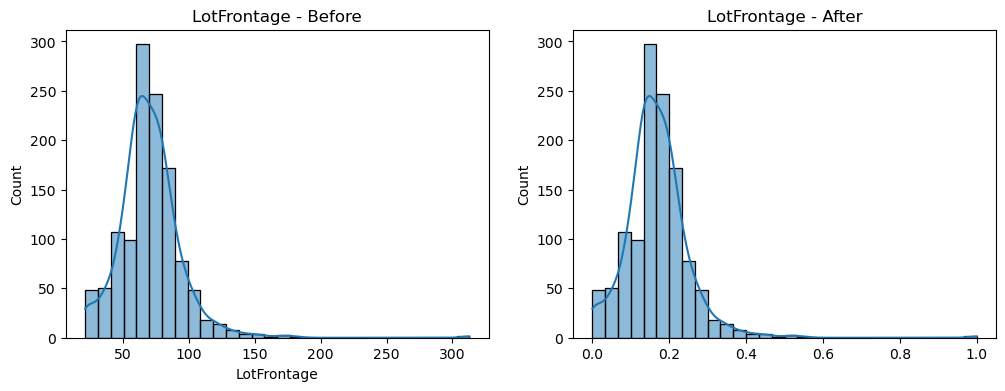

In [252]:
# ---------------------------------------------------
# 2. MinMax Scaling (bounded features: OverallQual [1-10])
# Formula: x' = (x - min) / (max - min)
# ---------------------------------------------------

col = "LotFrontage"
scaler = MinMaxScaler()
lot_scaled = scaler.fit_transform(df[[col]])
print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(pd.Series(lot_scaled.flatten())))
compare_distribution(df[col], lot_scaled.flatten(), col)